In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
# load all data
train = pd.read_csv('../data/raw/train_values.csv')
labels = pd.read_csv('../data/raw/train_labels.csv')
test = pd.read_csv('../data/raw/test_values.csv')


In [3]:
train

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,0
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,0
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,0
3,590882,22,418,10694,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,0
4,201944,11,131,1488,3,30,8,9,t,r,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260596,688636,25,1335,1621,1,55,6,3,n,r,...,0,0,0,0,0,0,0,0,0,0
260597,669485,17,715,2060,2,0,6,5,t,r,...,0,0,0,0,0,0,0,0,0,0
260598,602512,17,51,8163,3,55,6,7,t,r,...,0,0,0,0,0,0,0,0,0,0
260599,151409,26,39,1851,2,10,14,6,t,r,...,0,0,0,0,0,0,0,0,0,0


In [4]:
test

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
0,300051,17,596,11307,3,20,7,6,t,r,...,0,0,0,0,0,0,0,0,0,0
1,99355,6,141,11987,2,25,13,5,t,r,...,1,0,0,0,0,0,0,0,0,0
2,890251,22,19,10044,2,5,4,5,t,r,...,0,0,0,0,0,0,0,0,0,0
3,745817,26,39,633,1,0,19,3,t,r,...,0,0,1,0,0,0,0,0,0,0
4,421793,17,289,7970,3,15,8,7,t,r,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86863,310028,4,605,3623,3,70,20,6,t,r,...,1,0,0,0,0,0,0,0,0,0
86864,663567,10,1407,11907,3,25,6,7,n,r,...,0,0,0,0,0,0,0,0,0,0
86865,1049160,22,1136,7712,1,50,3,3,t,r,...,0,0,0,0,0,0,0,0,0,0
86866,442785,6,1041,912,2,5,9,5,t,r,...,0,0,0,0,0,0,0,0,0,0


In [5]:
labels

,building_id,damage_grade
0,802906,3
1,28830,2
2,94947,3
3,590882,2
4,201944,3
...,...,...
260596,688636,2
260597,669485,3
260598,602512,3
260599,151409,2


In [6]:
# shape of all data 
print("Shape of train:",train.shape)
print("Shape of labels:",labels.shape)
print("Shape of test:",test.shape)


Shape of train: (260601, 39)
Shape of labels: (260601, 2)
Shape of test: (86868, 39)


In [7]:
# counts of labels 
labels['damage_grade'].value_counts()

damage_grade
2    148259
3     87218
1     25124
Name: count, dtype: int64

(array([ 25124.,      0.,      0.,      0.,      0., 148259.,      0.,
             0.,      0.,  87218.]),
 array([1. , 1.2, 1.4, 1.6, 1.8, 2. , 2.2, 2.4, 2.6, 2.8, 3. ]),
 <BarContainer object of 10 artists>)

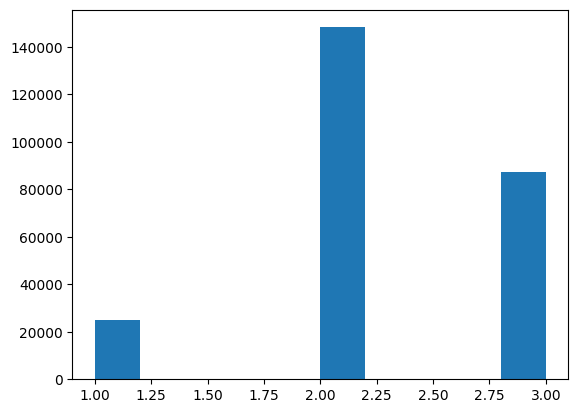

In [8]:
plt.hist(labels['damage_grade'])

In [9]:
train.describe()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,...,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
count,2.606010e+05,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,...,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000
mean,5.256755e+05,13.900353,701.074685,6257.876148,2.129723,26.535029,8.018051,5.434365,0.088645,0.761935,...,0.064378,0.033626,0.008101,0.000940,0.000361,0.001071,0.000188,0.000146,0.000088,0.005119
std,3.045450e+05,8.033617,412.710734,3646.369645,0.727665,73.565937,4.392231,1.918418,0.284231,0.425900,...,0.245426,0.180265,0.089638,0.030647,0.018989,0.032703,0.013711,0.012075,0.009394,0.071364
min,4.000000e+00,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.611900e+05,7.000000,350.000000,3073.000000,2.000000,10.000000,5.000000,4.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5.257570e+05,12.000000,702.000000,6270.000000,2.000000,15.000000,7.000000,5.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,7.897620e+05,21.000000,1050.000000,9412.000000,2.000000,30.000000,9.000000,6.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.052934e+06,30.000000,1427.000000,12567.000000,9.000000,995.000000,100.000000,32.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [10]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 39 columns):
 #   Column                                  Non-Null Count   Dtype
---  ------                                  --------------   -----
 0   building_id                             260601 non-null  int64
 1   geo_level_1_id                          260601 non-null  int64
 2   geo_level_2_id                          260601 non-null  int64
 3   geo_level_3_id                          260601 non-null  int64
 4   count_floors_pre_eq                     260601 non-null  int64
 5   age                                     260601 non-null  int64
 6   area_percentage                         260601 non-null  int64
 7   height_percentage                       260601 non-null  int64
 8   land_surface_condition                  260601 non-null  str  
 9   foundation_type                         260601 non-null  str  
 10  roof_type                               260601 non-null  str  
 11  ground_floo

In [11]:
train.isnull().sum()

building_id                               0
geo_level_1_id                            0
geo_level_2_id                            0
geo_level_3_id                            0
count_floors_pre_eq                       0
age                                       0
area_percentage                           0
height_percentage                         0
land_surface_condition                    0
foundation_type                           0
roof_type                                 0
ground_floor_type                         0
other_floor_type                          0
position                                  0
plan_configuration                        0
has_superstructure_adobe_mud              0
has_superstructure_mud_mortar_stone       0
has_superstructure_stone_flag             0
has_superstructure_cement_mortar_stone    0
has_superstructure_mud_mortar_brick       0
has_superstructure_cement_mortar_brick    0
has_superstructure_timber                 0
has_superstructure_bamboo       

(array([5.9738e+04, 7.4906e+04, 5.6548e+04, 2.8738e+04, 1.5270e+04,
        9.2900e+03, 4.7350e+03, 2.4870e+03, 3.9020e+03, 1.4990e+03,
        1.4530e+03, 1.2100e+02, 2.1700e+02, 1.4000e+01, 1.2000e+01,
        1.4300e+02, 8.0000e+00, 1.1000e+01, 8.0000e+00, 5.0000e+00,
        1.0600e+02, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.00

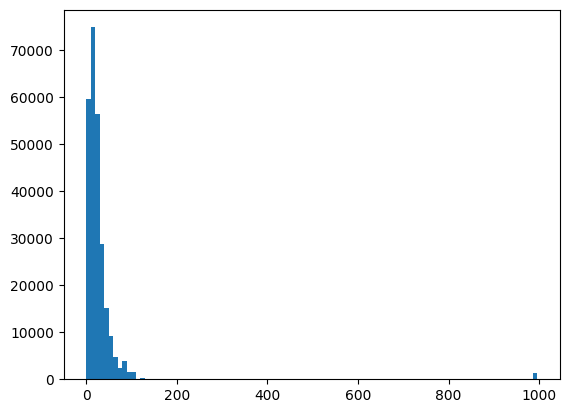

In [12]:
plt.hist(train['age'],bins=100)

In [13]:
# merging labels and train for better removal 
train= pd.merge(train, labels, on='building_id')

In [14]:
# removing all the outliers from age ]
train = train[train['age'] < 500]

In [15]:
train.age.max()

np.int64(200)

In [16]:
train[train['age'] < 500]['age'].value_counts()

age
10     38896
15     36010
5      33697
20     32182
0      26041
25     24366
30     18028
35     10710
40     10559
50      7257
45      4711
60      3612
80      3055
55      2033
70      1975
100     1364
65      1123
90      1085
85       847
75       512
95       414
120      180
150      142
200      106
110      100
105       89
125       37
115       21
130        9
140        9
180        7
160        6
170        6
175        5
135        5
190        3
145        3
195        2
165        2
155        1
185        1
Name: count, dtype: int64

In [17]:
train[train['age'] < 500]

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,3
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,2
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,3
3,590882,22,418,10694,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,2
4,201944,11,131,1488,3,30,8,9,t,r,...,0,0,0,0,0,0,0,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260596,688636,25,1335,1621,1,55,6,3,n,r,...,0,0,0,0,0,0,0,0,0,2
260597,669485,17,715,2060,2,0,6,5,t,r,...,0,0,0,0,0,0,0,0,0,3
260598,602512,17,51,8163,3,55,6,7,t,r,...,0,0,0,0,0,0,0,0,0,3
260599,151409,26,39,1851,2,10,14,6,t,r,...,0,0,0,0,0,0,0,0,0,2


In [18]:
bucket_mean = (
    train
    .groupby('age')['damage_grade']
    .mean()
    .reset_index()
)

print(bucket_mean)

    age  damage_grade
0     0      1.957529
1     5      2.103481
2    10      2.200689
3    15      2.263455
4    20      2.300510
5    25      2.329599
6    30      2.349678
7    35      2.351074
8    40      2.369827
9    45      2.354277
10   50      2.380460
11   55      2.358091
12   60      2.372370
13   65      2.352627
14   70      2.365063
15   75      2.349609
16   80      2.405892
17   85      2.332940
18   90      2.348387
19   95      2.357488
20  100      2.317449
21  105      2.348315
22  110      2.340000
23  115      2.428571
24  120      2.433333
25  125      2.297297
26  130      2.666667
27  135      1.800000
28  140      2.111111
29  145      2.000000
30  150      2.302817
31  155      3.000000
32  160      2.500000
33  165      2.000000
34  170      2.333333
35  175      2.400000
36  180      2.285714
37  185      2.000000
38  190      2.333333
39  195      2.000000
40  200      2.339623


In [19]:
train.dtypes


building_id                               int64
geo_level_1_id                            int64
geo_level_2_id                            int64
geo_level_3_id                            int64
count_floors_pre_eq                       int64
age                                       int64
area_percentage                           int64
height_percentage                         int64
land_surface_condition                      str
foundation_type                             str
roof_type                                   str
ground_floor_type                           str
other_floor_type                            str
position                                    str
plan_configuration                          str
has_superstructure_adobe_mud              int64
has_superstructure_mud_mortar_stone       int64
has_superstructure_stone_flag             int64
has_superstructure_cement_mortar_stone    int64
has_superstructure_mud_mortar_brick       int64
has_superstructure_cement_mortar_brick  

<Axes: xlabel='count_floors_pre_eq', ylabel='proportion'>

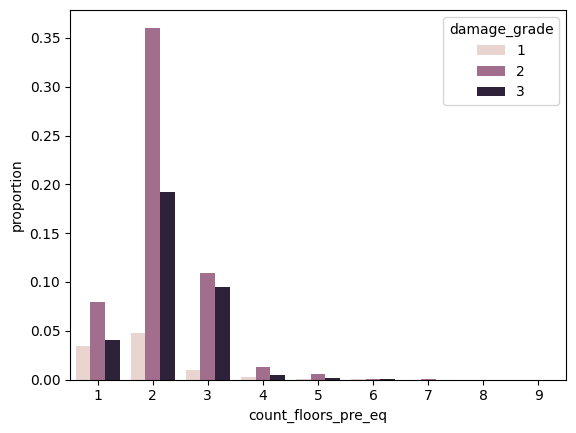

In [20]:
sns.countplot(x='count_floors_pre_eq', hue='damage_grade', data=train, stat='proportion' )

In [21]:
train.groupby('count_floors_pre_eq')['damage_grade'].value_counts(normalize=True)

count_floors_pre_eq  damage_grade
1                    2               0.514179
                     3               0.263881
                     1               0.221941
2                    2               0.600042
                     3               0.319883
                     1               0.080075
3                    2               0.511657
                     3               0.442908
                     1               0.045435
4                    2               0.620594
                     3               0.248423
                     1               0.130983
5                    2               0.657800
                     3               0.228133
                     1               0.114067
6                    2               0.637255
                     1               0.250000
                     3               0.112745
7                    2               0.641026
                     1               0.256410
                     3               0.102564


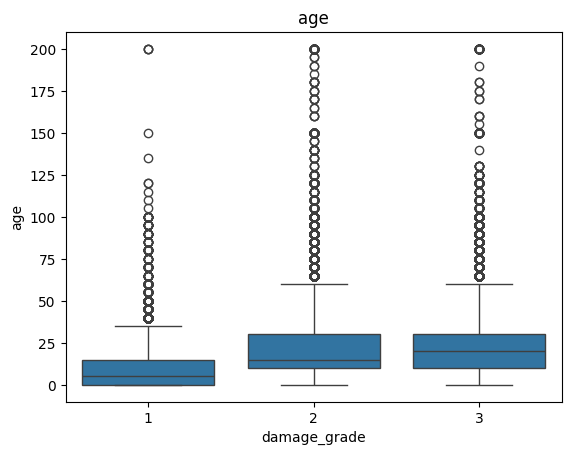

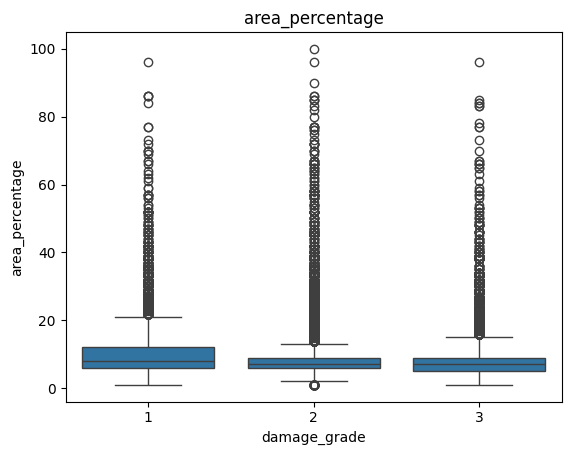

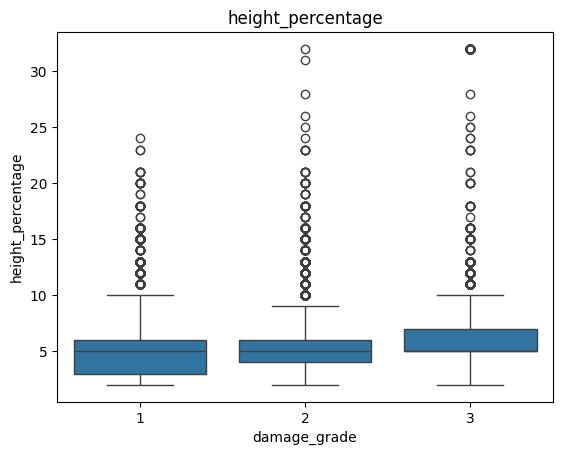

In [22]:
# plots for all 
# for continues features 
cont_cols = ['age', 'area_percentage', 'height_percentage']

for col in cont_cols:
    sns.boxplot(x='damage_grade', y=col, data=train)
    plt.title(col)
    plt.show()

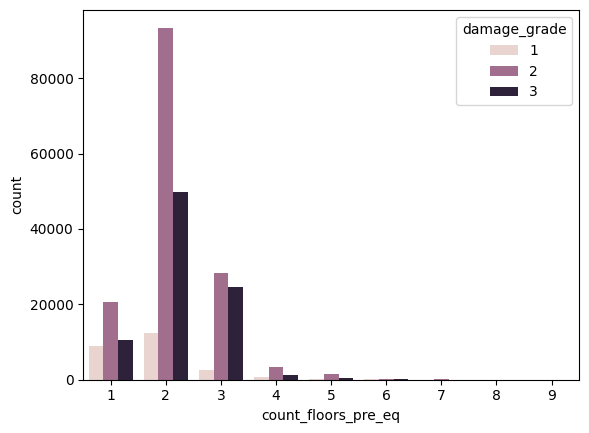

In [23]:
# for discrete

sns.countplot(x='count_floors_pre_eq', hue='damage_grade', data=train)
plt.show()

In [24]:
# for binary cols 

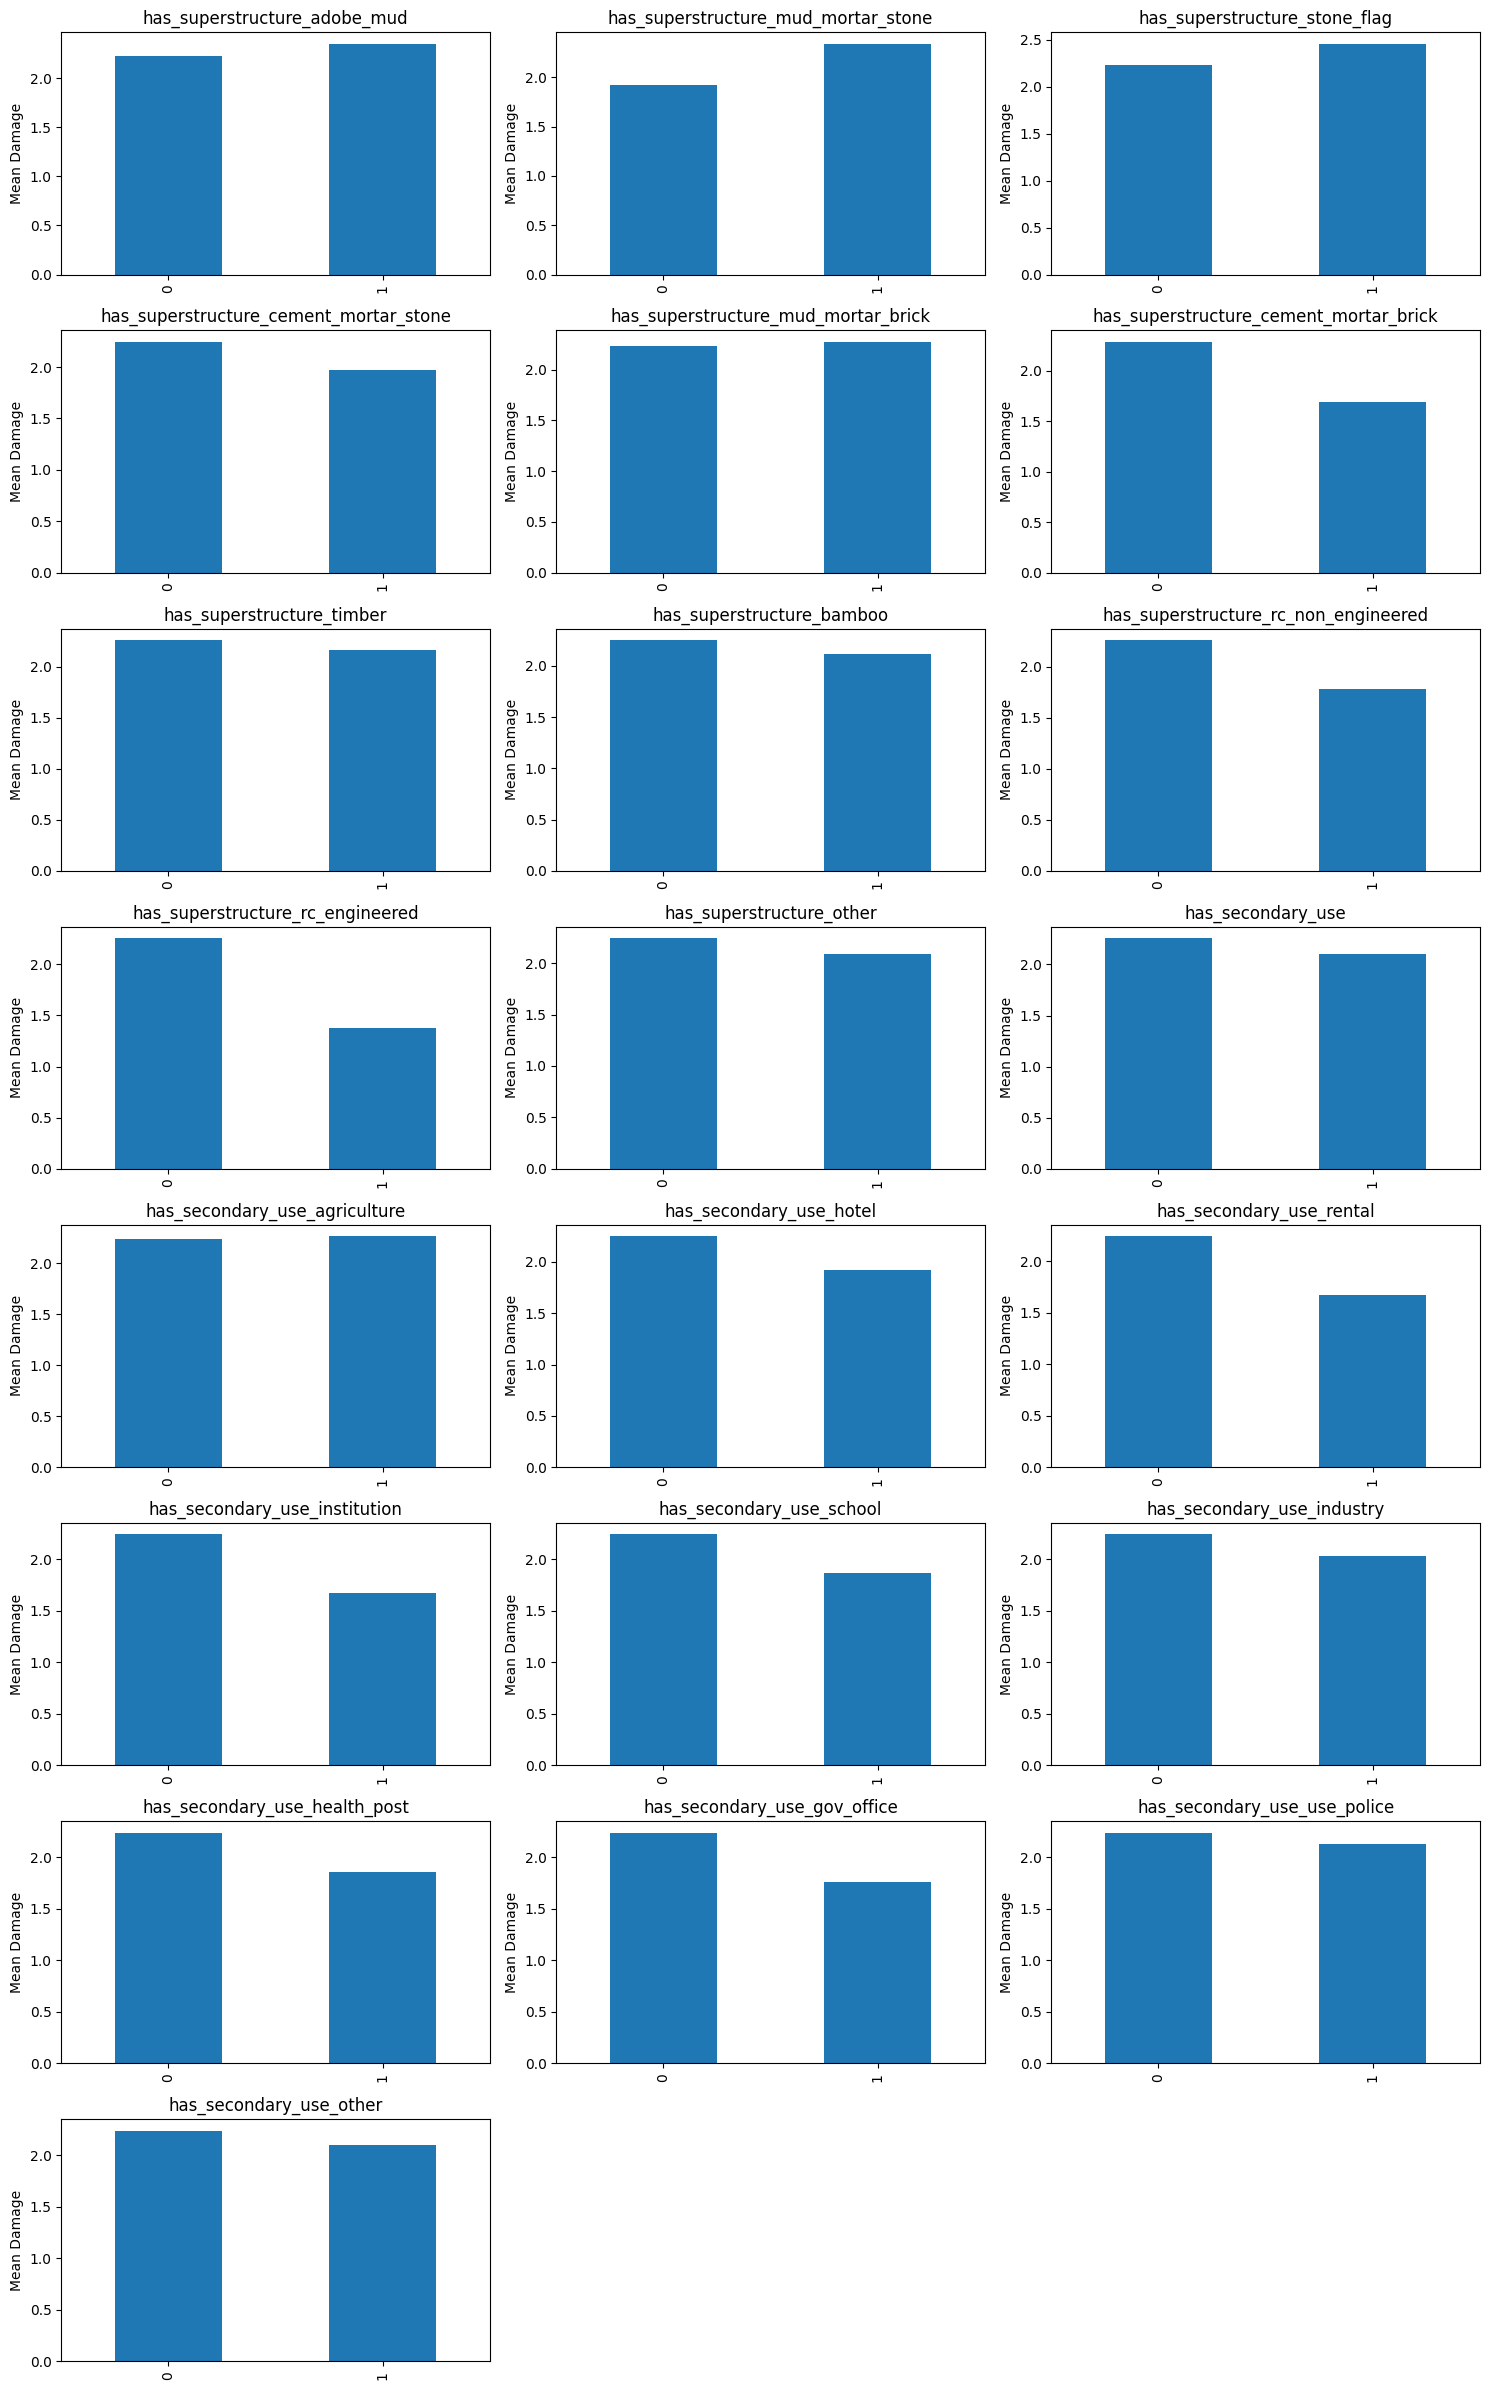

In [25]:
import matplotlib.pyplot as plt

binary_cols = [
    c for c in train.columns
    if train[c].nunique() == 2 and c != 'damage_grade'
]

n_cols = 3
n_rows = (len(binary_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(binary_cols):
    train.groupby(col)['damage_grade'].mean().plot(
        kind='bar',
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Mean Damage')

# remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

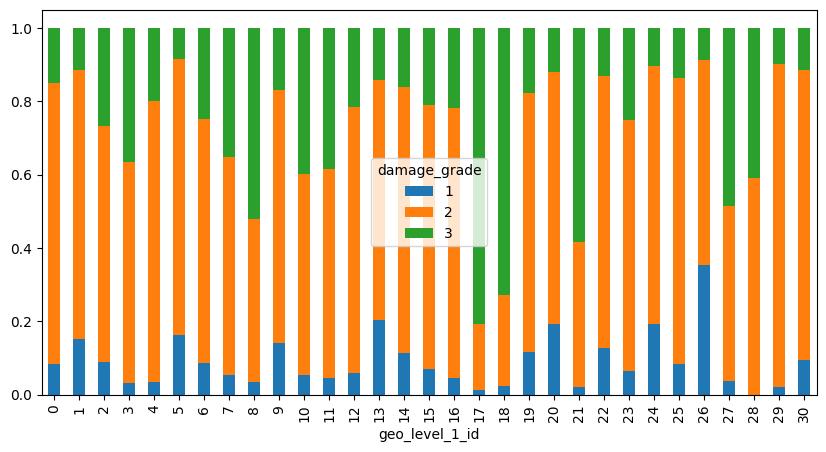

In [26]:
# for geo_levels
pd.crosstab(train['geo_level_1_id'], train['damage_grade'], normalize='index')\
  .plot(kind='bar', stacked=True, figsize=(10,5))
plt.show()

In [27]:
train.groupby('geo_level_1_id')['damage_grade'].mean()

geo_level_1_id
0     2.065898
1     1.960755
2     2.178005
3     2.331609
4     2.162186
5     1.921382
6     2.161336
7     2.296940
8     2.484982
9     2.026023
10    2.342539
11    2.337813
12    2.156882
13    1.938790
14    2.048100
15    2.138289
16    2.171745
17    2.794418
18    2.704574
19    2.061828
20    1.926397
21    2.562584
22    2.003547
23    2.186441
24    1.907990
25    2.052992
26    1.730858
27    2.448506
28    2.407547
29    2.078283
30    2.019820
Name: damage_grade, dtype: float64

In [28]:
train[['area_percentage', 'height_percentage', 'age', 'count_floors_pre_eq', 'damage_grade']].corr()

,area_percentage,height_percentage,age,count_floors_pre_eq,damage_grade
area_percentage,1.000000,0.196877,-0.027806,0.100979,-0.124860
height_percentage,0.196877,1.000000,0.204745,0.772625,0.048442
age,-0.027806,0.204745,1.000000,0.298723,0.148396
count_floors_pre_eq,0.100979,0.772625,0.298723,1.000000,0.122937
damage_grade,-0.124860,0.048442,0.148396,0.122937,1.000000


In [29]:
cat_cols = train.select_dtypes(include='object').columns

/tmp/ipykernel_69925/3167773848.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train.select_dtypes(include='object').columns


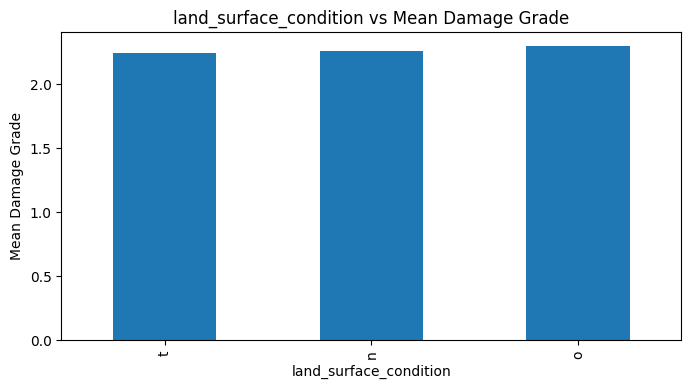

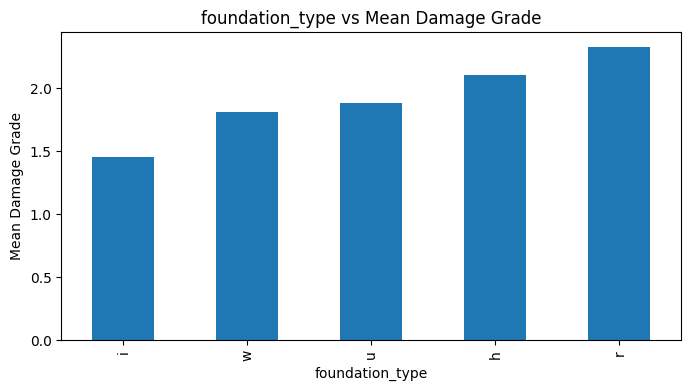

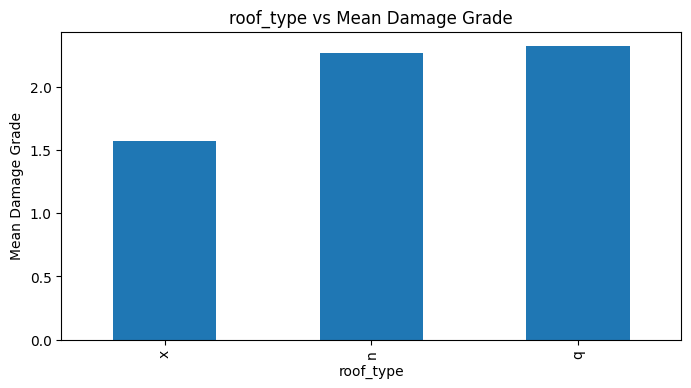

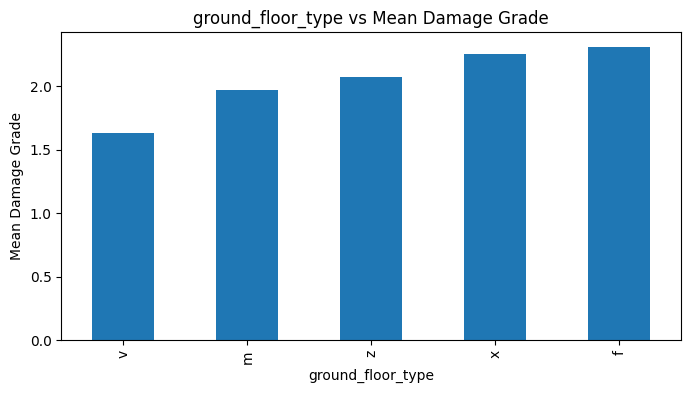

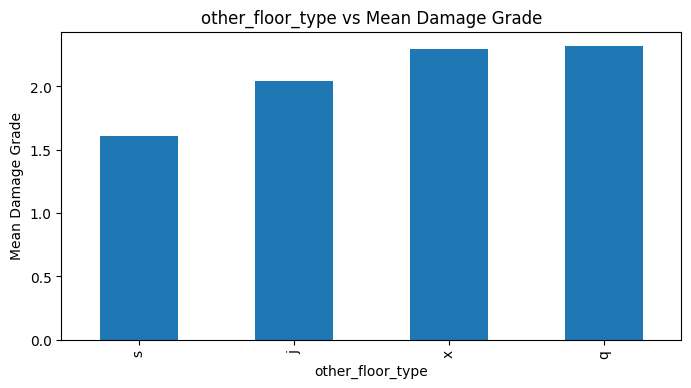

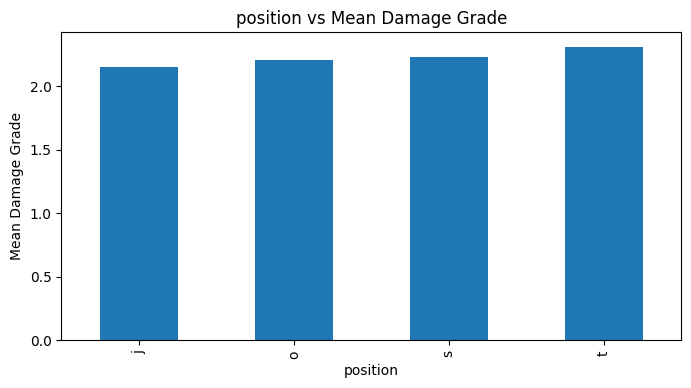

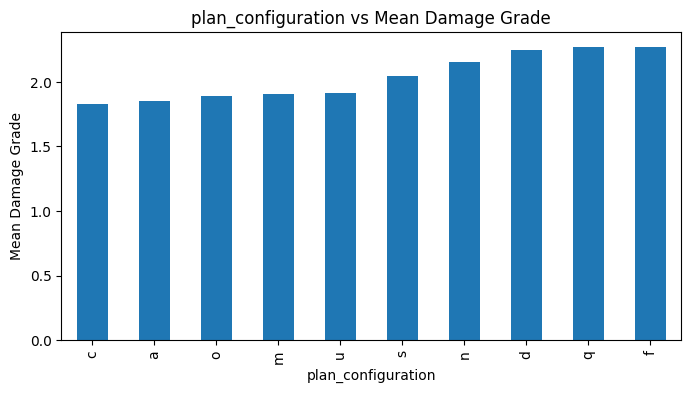

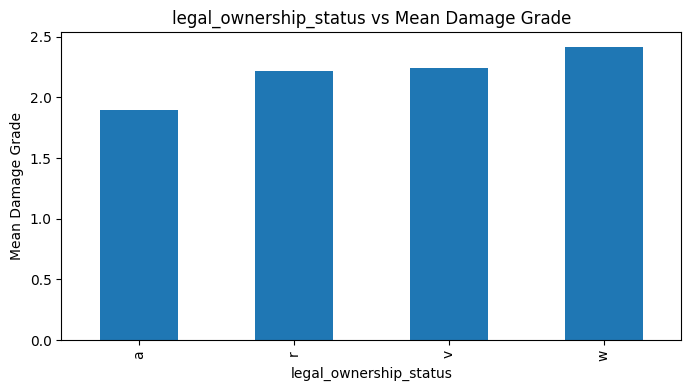

In [30]:
import matplotlib.pyplot as plt

for col in cat_cols:
    plt.figure(figsize=(8,4))
    train.groupby(col)['damage_grade'].mean().sort_values().plot(kind='bar')
    plt.title(f"{col} vs Mean Damage Grade")
    plt.ylabel("Mean Damage Grade")
    plt.show()

In [31]:
train

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,3
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,2
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,3
3,590882,22,418,10694,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,2
4,201944,11,131,1488,3,30,8,9,t,r,...,0,0,0,0,0,0,0,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260596,688636,25,1335,1621,1,55,6,3,n,r,...,0,0,0,0,0,0,0,0,0,2
260597,669485,17,715,2060,2,0,6,5,t,r,...,0,0,0,0,0,0,0,0,0,3
260598,602512,17,51,8163,3,55,6,7,t,r,...,0,0,0,0,0,0,0,0,0,3
260599,151409,26,39,1851,2,10,14,6,t,r,...,0,0,0,0,0,0,0,0,0,2


In [32]:
train.isna().sum()

building_id                               0
geo_level_1_id                            0
geo_level_2_id                            0
geo_level_3_id                            0
count_floors_pre_eq                       0
age                                       0
area_percentage                           0
height_percentage                         0
land_surface_condition                    0
foundation_type                           0
roof_type                                 0
ground_floor_type                         0
other_floor_type                          0
position                                  0
plan_configuration                        0
has_superstructure_adobe_mud              0
has_superstructure_mud_mortar_stone       0
has_superstructure_stone_flag             0
has_superstructure_cement_mortar_stone    0
has_superstructure_mud_mortar_brick       0
has_superstructure_cement_mortar_brick    0
has_superstructure_timber                 0
has_superstructure_bamboo       